In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [1]:
day_1 = pd.read_csv("prices_round_2_day_0.csv", sep=';')
day_0 = pd.read_csv("prices_round_2_day_1.csv", sep=';')
day_2 = pd.read_csv("prices_round_2_day_-1.csv", sep=';')


day_1['timestamp'] += day_2['timestamp'].max() + 1
day_0['timestamp'] += day_1['timestamp'].max() + 1

combined_df = pd.concat([day_2, day_1, day_0], ignore_index=True)

max(combined_df['timestamp']) 

NameError: name 'pd' is not defined

In [32]:
combined_df

,day,timestamp,product,bid_price_1,bid_volume_1,bid_price_2,bid_volume_2,bid_price_3,bid_volume_3,ask_price_1,ask_volume_1,ask_price_2,ask_volume_2,ask_price_3,ask_volume_3,mid_price,profit_and_loss
0,-1,0,CROISSANTS,4304,112,NaN,NaN,NaN,NaN,4305,112,NaN,NaN,NaN,NaN,4304.5,0.0
1,-1,0,JAMS,6670,66,6669.0,137.0,NaN,NaN,6671,66,6672.0,137.0,NaN,NaN,6670.5,0.0
2,-1,0,SQUID_INK,2005,1,2002.0,31.0,NaN,NaN,2006,31,NaN,NaN,NaN,NaN,2005.5,0.0
3,-1,0,PICNIC_BASKET1,59284,20,59283.0,18.0,NaN,NaN,59294,2,59295.0,36.0,NaN,NaN,59289.0,0.0
4,-1,0,PICNIC_BASKET2,30606,20,30605.0,18.0,NaN,NaN,30612,20,30613.0,18.0,NaN,NaN,30609.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239995,1,2999702,JAMS,6519,204,NaN,NaN,NaN,NaN,6521,204,NaN,NaN,NaN,NaN,6520.0,0.0
239996,1,2999702,RAINFOREST_RESIN,9995,20,NaN,NaN,NaN,NaN,10005,20,NaN,NaN,NaN,NaN,10000.0,0.0
239997,1,2999702,SQUID_INK,1799,20,NaN,NaN,NaN,NaN,1802,20,NaN,NaN,NaN,NaN,1800.5,0.0
239998,1,2999702,PICNIC_BASKET1,58713,15,58712.0,21.0,NaN,NaN,58724,15,58725.0,21.0,NaN,NaN,58718.5,0.0


In [33]:
def extract_prices(df, symbol):
    filtered = df[df['product'] == symbol]
    prices_only = filtered[['timestamp', 'mid_price']]
    return prices_only

def calculate_mid_price(row):
    best_bid = row['bid_price_1']
    best_ask = row['ask_price_1']
    
    # Gestion des valeurs manquantes potentielles
    if pd.notna(best_bid) and pd.notna(best_ask):
        return (best_bid + best_ask) / 2
    elif pd.notna(best_bid):
        return best_bid
    elif pd.notna(best_ask):
        return best_ask
    else:
        return None


combined_df['mid_price'] = combined_df.apply(calculate_mid_price, axis=1)




In [ ]:
croissants_prices = extract_prices(combined_df, 'CROISSANTS')
jams_prices = extract_prices(combined_df, 'JAMS')
djembe_prices = extract_prices(combined_df, 'DJEMBES')
basket1_prices = extract_prices(combined_df, 'PICNIC_BASKET1')
basket2_prices = extract_prices(combined_df, 'PICNIC_BASKET2')

# Index Arb Test

In [36]:
croissants = croissants_prices[['timestamp', 'mid_price']].rename(columns={'mid_price': 'croissant_price'})
jams = jams_prices[['timestamp', 'mid_price']].rename(columns={'mid_price': 'jam_price'})
djembe = djembe_prices[['timestamp', 'mid_price']].rename(columns={'mid_price': 'djembe_price'})

merged_1 = croissants.merge(jams, on='timestamp').merge(djembe, on='timestamp')
merged_2 =merged_1.copy()

merged_1['basket_value'] = (
    6 * merged_1['croissant_price'] +
    3 * merged_1['jam_price'] +
    1 * merged_1['djembe_price']
)

merged_2['basket_value'] = (
    4 * merged_1['croissant_price'] +
    2 * merged_1['jam_price'] 
)

synthetic_basket1 = merged_1.set_index('timestamp')[['basket_value']]

synthetic_basket2 = merged_2.set_index('timestamp')[['basket_value']]



In [37]:
spread_basket1_instant = basket1_prices.merge(synthetic_basket1, on='timestamp')
spread_basket2_instant = basket2_prices.merge(synthetic_basket2, on='timestamp')

In [38]:
spread_basket1_instant["spread"] = -spread_basket1_instant['mid_price'] + spread_basket1_instant['basket_value']
spread_basket2_instant["spread"] = spread_basket2_instant['mid_price'] - spread_basket2_instant['basket_value']

In [39]:
spread_basket1_instant

,timestamp,mid_price,basket_value,spread
0,0,59289.0,59289.0,0.0
1,100,59287.0,59288.5,1.5
2,200,59293.5,59290.5,-3.0
3,300,59293.5,59293.0,-0.5
4,400,59292.0,59301.5,9.5
...,...,...,...,...
29995,2999302,58720.5,58589.5,-131.0
29996,2999402,58719.5,58587.0,-132.5
29997,2999502,58715.0,58587.5,-127.5
29998,2999602,58725.5,58589.0,-136.5


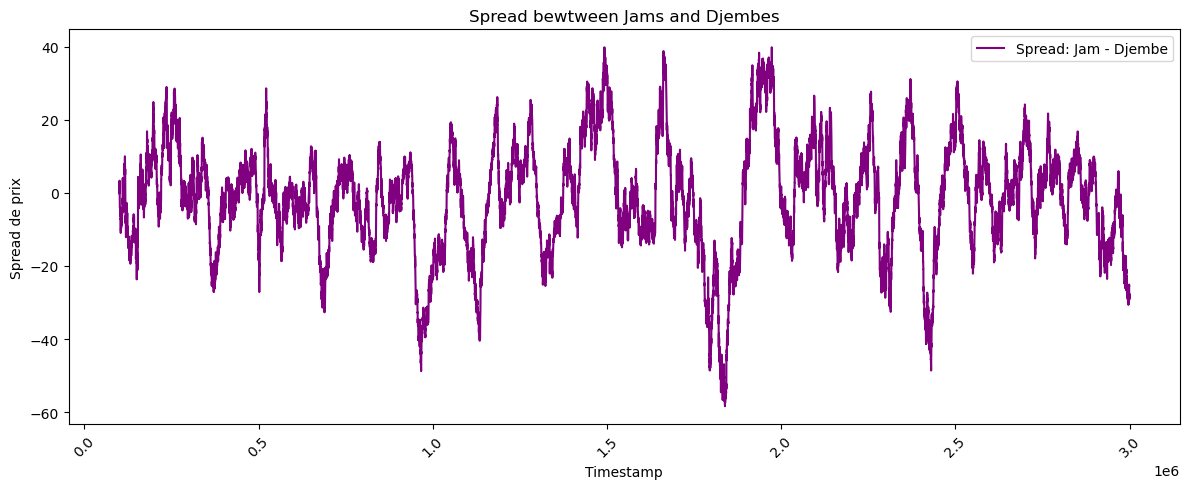

In [ ]:
import matplotlib.pyplot as plt

jams = jams_prices[['timestamp', 'mid_price']].rename(columns={'mid_price': 'jam_price'})
djembe = djembe_prices[['timestamp', 'mid_price']].rename(columns={'mid_price': 'djembe_price'})

spread_df = jams.merge(djembe, on='timestamp', how='inner')


spread_df['spread'] = spread_df['jam_price'] - spread_df['djembe_price']
window = 1000
spread_df['spread_ma'] = spread_df['spread'].rolling(window=window).mean()
spread_df['spread_centered'] = spread_df['spread'] - spread_df['spread_ma']


# Plot
plt.figure(figsize=(12, 5))
plt.plot(spread_df['timestamp'], spread_df['spread_centered'], label='Spread: Jam - Djembe', color='purple')

plt.title('Spread bewtween Jams and Djembes')   
plt.xlabel('Timestamp')
plt.ylabel('Spread de prix')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


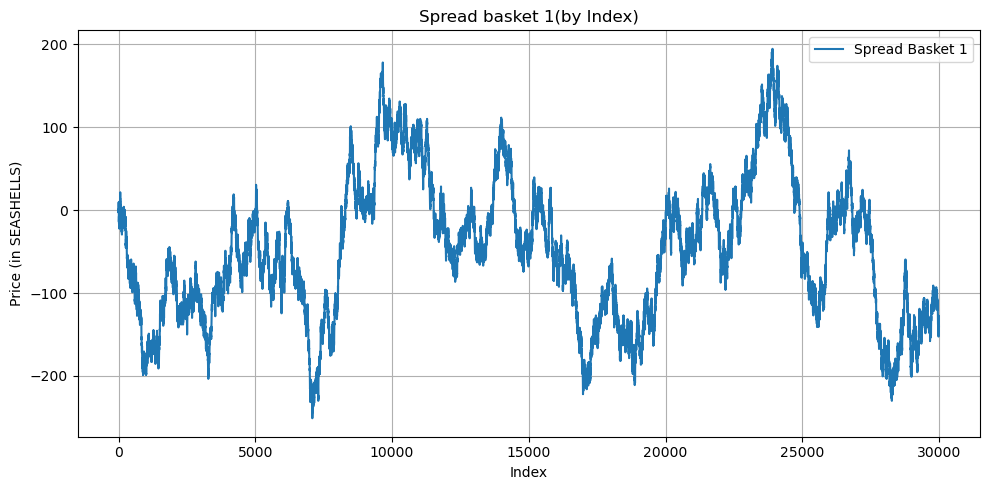

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(spread_basket1_instant.index, spread_basket1_instant["spread"], label='Spread Basket 1'
          , linestyle='-')

plt.xlabel('Index')
plt.ylabel('Price (in SEASHELLS)')
plt.title('Spread basket 1(by Index)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [42]:
spread_basket1_instant["spread"].mean()

-48.762433333333334

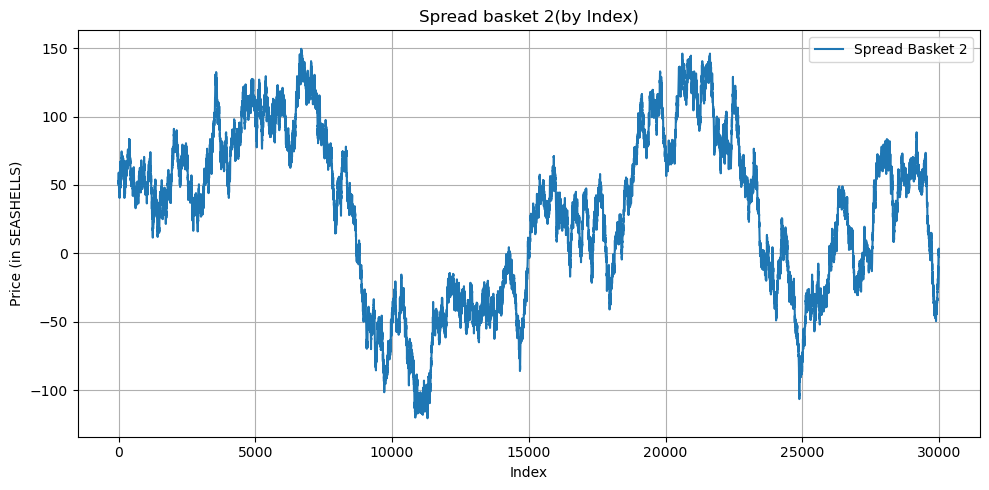

In [177]:
plt.figure(figsize=(10, 5))
plt.plot(spread_basket2_instant.index, spread_basket2_instant["spread"] , label='Spread Basket 2'
          , linestyle='-')

plt.xlabel('Index')
plt.ylabel('Price (in SEASHELLS)')
plt.title('Spread basket 2(by Index)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [44]:
print(np.median(spread_basket1_instant["spread"]))
print(np.median(spread_basket2_instant["spread"]))

-51.0
38.5


Run mean reversion on spread : if above threshold =>short basket long synthetic / : if below threshold => long basket short synthtic